In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import  RandomForestRegressor,HistGradientBoostingRegressor

from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

In [64]:
# Configurations for project

pd.set_option('display.max_columns',None)
pd.set_option('display.float_format',lambda x:f"{x:.3f}")
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    "axes.titlesize":10,
    "axes.labelsize":9,
    "xtick.labelsize":8,
    "ytick.labelsize":8,
})



RANDOM_STATE=42
CSV_PATH="../data/california_housing.csv"
TARGET_COL="median_house_value"

In [65]:
df = pd.read_csv(CSV_PATH)

In [66]:
print("DataFrame Shape",df.shape)

DataFrame Shape (20640, 10)


In [67]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [68]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [70]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols =df.select_dtypes(include=['object']).columns.tolist()


print("target column:",TARGET_COL)
print("Numerical Columns", num_cols)
print("Categorical Columns",cat_cols)

target column: median_house_value
Numerical Columns ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical Columns ['ocean_proximity']


/tmp/ipykernel_25631/1688284369.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols =df.select_dtypes(include=['object']).columns.tolist()


In [71]:
#  Checking missing values

print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [72]:
# To check thow many colums have frequent common values top 20.
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.370    128
-118.250    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
34.110    162
33.980    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [73]:
# Duplicates
duplicate_mask=df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:",num_duplicates)

Number of duplicate rows: 0


In [74]:
# If there are duplicates value drpop that value thats all

df = df.drop_duplicates()
print("Shape after dropping duplicates",df.shape)

Shape after dropping duplicates (20640, 10)


In [75]:
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


In [76]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


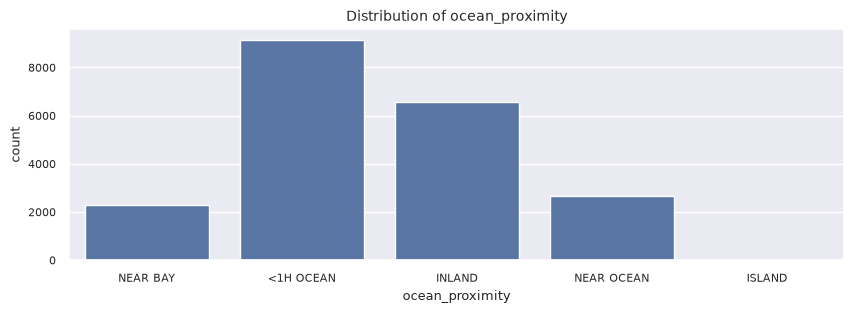

In [77]:
# Countplot for categorical column

for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col,data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [78]:
for col in cat_cols:
    print(df[col].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Text(0.5, 1.0, 'Targe distribution')

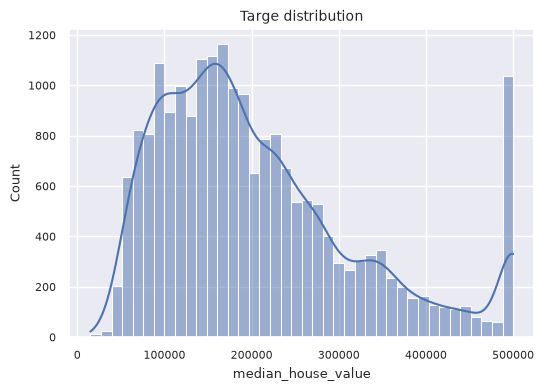

In [79]:
# target column distribution

plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL],bins=40,kde=True)
plt.title("Targe distribution")

In [80]:
df[TARGET_COL].value_counts()

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
422900.000      1
349400.000      1
425800.000      1
200700.000      1
47000.000       1
Name: count, Length: 3842, dtype: int64

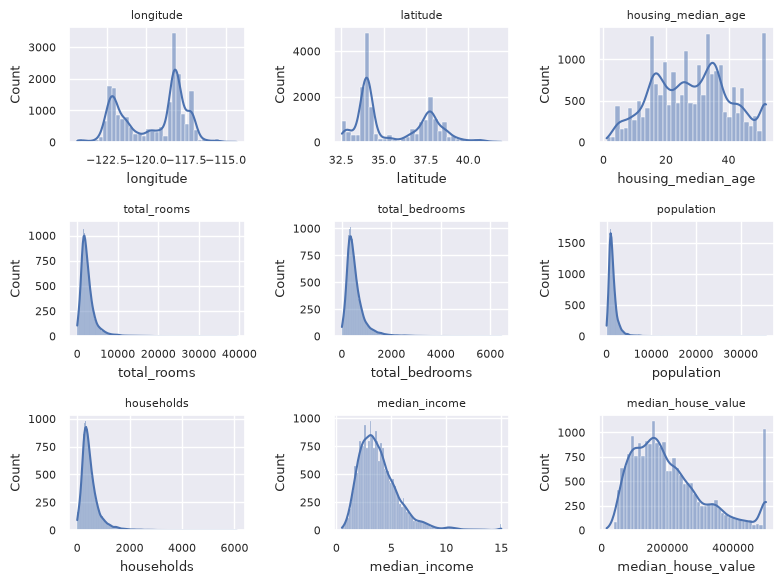

In [81]:
fig, axes =plt.subplots(3,3, figsize=(8,6))
axes =axes.flatten()

for i,col in enumerate(num_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)

plt.tight_layout()
plt.show()

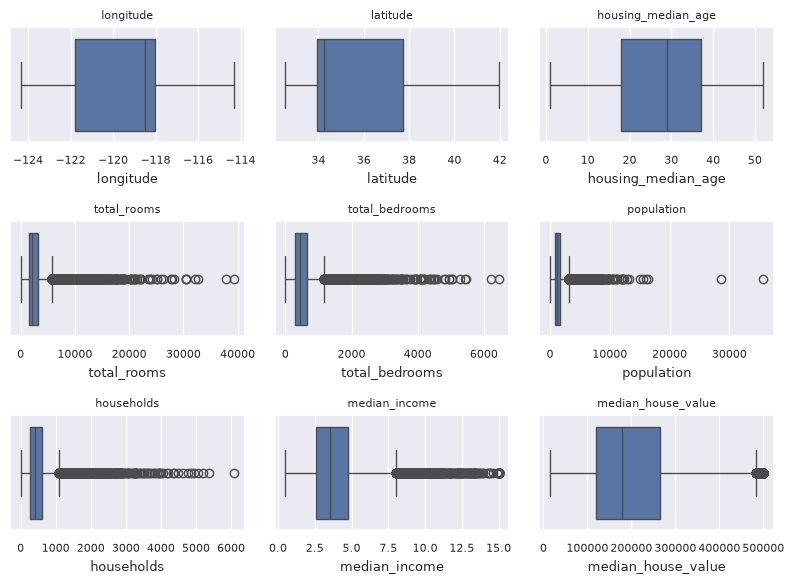

In [82]:
fig, axes =plt.subplots(3,3, figsize=(8,6))
axes =axes.flatten()

for i,col in enumerate(num_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)

plt.tight_layout()
plt.show()

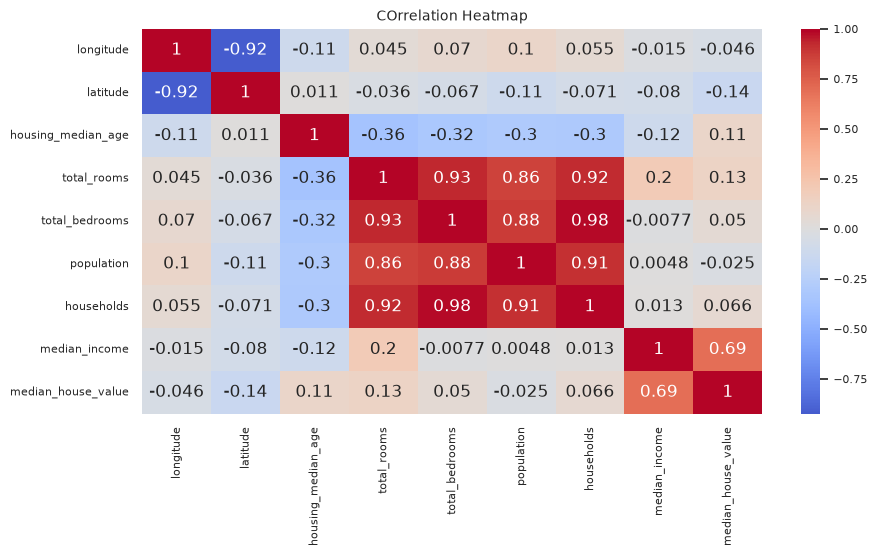

In [83]:
# Identify the presence of highly coorelated columns and feature relationships

plt.figure(figsize=(10,5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("COrrelation Heatmap")
plt.show()

In [84]:
# Corelation with target

corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


# Data Preprocessing

In [85]:
# Seprate features and target

X=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]

In [86]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [87]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [88]:
# train test split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)

In [89]:
print("Train Shape",X_train.shape)
print("Test Shape",X_test.shape)

Train Shape (16512, 9)
Test Shape (4128, 9)


# Preprocessing Pipeline

In [98]:
numerical_features = X_train.select_dtypes(include=(np.number)).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=(np.number)).columns.tolist()
print(numerical_features)
print(categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy="most_frequent")),
        ("obehot",OneHotEncoder(handle_unknown="ignore"))
    ]
)


# preprocessing pipeline

preprocess = ColumnTransformer(
    transformers=[
        ("num",numerical_transformer,numerical_features),
        ("cat",categorical_transformer,categorical_features),
    ]
)

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
['ocean_proximity']


# Baseline Model (No CV, No Tuning)

In [99]:
baseline_pipeline=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',LinearRegression())
    ]
)

In [100]:
# preprocess data  and train the baseline model

baseline_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. 

In [101]:
training_baseline_pred = baseline_pipeline.predict(X_train)
test_baseline_pred = baseline_pipeline.predict(X_test)

In [102]:
training_baseline_pred

array([188628.0772436 , 290379.8948687 , 250985.48476349, ...,
       194624.05524513, 281818.52422052, 271572.84185839], shape=(16512,))

In [103]:
train_baseline_rmse=root_mean_squared_error(y_train,training_baseline_pred)
train_baseline_mae=mean_absolute_error(y_train,training_baseline_pred)
train_baseline_r2=r2_score(y_train,training_baseline_pred)


print("\n=== TRAIN BASELINE METRICS (Linear Regression) ===")
print(f"RMSE:{train_baseline_rmse:.3f}")
print(f"MAE:{train_baseline_mae:.3f}")
print(f"R2:{train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (Linear Regression) ===
RMSE:68433.937
MAE:49594.842
R2:0.650


In [106]:
# test data

test_baseline_rmse=root_mean_squared_error(y_test,test_baseline_pred)
test_baseline_mae=mean_absolute_error(y_test,test_baseline_pred)
test_baseline_r2=r2_score(y_test,test_baseline_pred)


print("\n=== TRAIN BASELINE METRICS (Linear Regression) ===")
print(f"RMSE:{test_baseline_rmse:.3f}")
print(f"MAE:{test_baseline_mae:.3f}")
print(f"R2:{test_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (Linear Regression) ===
RMSE:70059.193
MAE:50670.489
R2:0.625


# Model Selection and Optimization


In [108]:
# models to try
models={
    'LinearRegression':LinearRegression(),
    'Ridge':Ridge(random_state=RANDOM_STATE),
    'Lasso':Lasso(random_state=RANDOM_STATE,max_iter=10000),
    'RandomForestRegressor':RandomForestRegressor(),
    'HistGB':HistGradientBoostingRegressor()
}

In [119]:
k=5
cv=KFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)

In [120]:
scoring={
    'rmse':"neg_root_mean_squared_error",
    'mae':"neg_mean_absolute_error",
    'r2':"r2"
}

In [ ]:
rows = []
for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ('preprocess',preprocess),
            ('model',model)
        ]
    )
    scores = cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    rows.append({
        "model":name,
        "cv_rmse":-scores["test_rmse"].mean(),
        "cv_mae":-scores["test_mae"].mean(),
        "cv_r2":-scores["test_r2"].mean()
    })

cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV Model Comparsion ===")
print(cv_results)